#### 확률적 경사 하강법(SGD: Stochastic Gradient Descent)
- 머신러닝에서도 많이 사용하지만 실질적으로는 딥러닝에서 많이 사용한다.   
- 데이터가 추가 되었을 경우의 머신러닝 처리 방법

1. 새로운 데이터로 모델을 추가하여 새롭게 학습하여 처리한다.    
2. 추가된 갯수만큼 기존의 데이터를 버리고 사용한다.   
3. 기존 모델을 수정하면서 사용한다(점진적 학습 방법)   


- Epoch : 훈련세트를 다 사용하였을 때 단계
- Mini Batch(미니 배치) 경사 하강법 : Hyper parameter, 보통 2의 배수 사용
- 배치 경사 하강법 : 샘플을 한번에 몽땅 꺼내면 컴퓨터 메모리나 CPU에 영향을 줄 수 있어서 거의 사용을 안하고 보통 확률적 경사 하강법이나 Mini Batch 경사 하강법을 사용한다.    



### 손실함수
- 머신 러닝 알고리즘이 에러율을 측정하는 함수   
- 손실함수 값이 적은 것이 정확도가 높은 것이다.   
- 확률적 경사하강법을 통해서 손실함수가 낮은 값을 찾는 것이다.
- 분류함수인 경우에는 정확도를 사용하는데 이 정확도의 값은 미분할 수가 없어서(연속성이 없어서) 손실함수로 사용할 수 없다.   
- 분류함수인 경우에는 로지스틱 손실함수, 이진크로스엔트로피 손실함수를 사용한다.

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
fish = pd.read_csv("../Data/fishes.csv")
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
# Feature Data
fish_input = fish.iloc[:,1:].to_numpy()
fish_input[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [6]:
fish_target = fish.iloc[:,0].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

### Train과 Test

In [17]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
  train_test_split(
    fish_input,
    fish_target,
    random_state=42
  )

### 표준화

In [18]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

---
### 확률적 경사 하강법의 분류 알고리즘 적용

In [19]:
from sklearn.linear_model import SGDClassifier

In [20]:
sc = SGDClassifier(loss='log_loss', # 로지스틱 손실함수
                    max_iter=10,
                    random_state=42 # 순서가 바뀐다
                  )

In [21]:
sc.fit(train_scaled, train_target)

SGDClassifier(loss='log_loss', max_iter=10, random_state=42)

In [25]:
print("train :", sc.score(train_scaled, train_target))
print("test  :", sc.score(test_scaled, test_target))

train : 0.8067226890756303
test  : 0.8


In [54]:
sc.partial_fit(train_scaled, train_target)

print("train :", sc.score(train_scaled, train_target))
print("test  :", sc.score(test_scaled, test_target))

train : 0.9159663865546218
test  : 0.9


- 규제가 작으면 과대적합
- 조기종료(Early Stopping) : 적합한 Epoch의 위치를 찾으면 종료한다.

In [55]:
import numpy as np

sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []

classes = np.unique(train_target)
classes

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [56]:
for _ in range(300):
  sc.partial_fit(train_scaled,train_target,classes=classes)
  train_score.append(sc.score(train_scaled,train_target))
  test_score.append(sc.score(test_scaled,test_target))

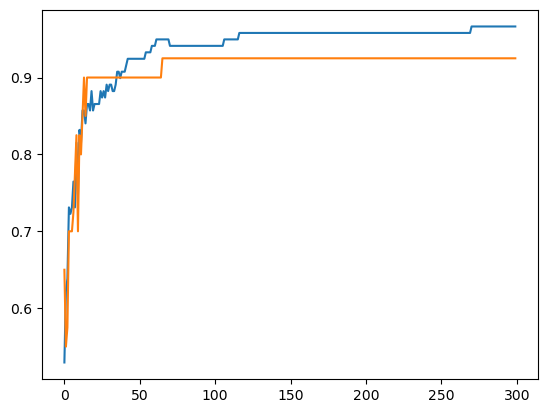

In [57]:
import matplotlib.pyplot as plt

plt.plot(train_score)
plt.plot(test_score)


plt.show()

> 100 정도의 Epoch가 좋은것 같다.

In [ ]:
# 새롭게 시작
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print("train :", sc.score(train_scaled, train_target))
print("test  :", sc.score(test_scaled, test_target))

train : 0.957983193277311
test  : 0.925


> tol=None : 조기종료 시점이나 현재는 정지 기준이 없고 반복 기간동안의 최적의 손실값보다 큰 경우 조기 종료한다.

In [66]:
# 새롭게 시작
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=0.001, random_state=42)
sc.fit(train_scaled, train_target)
print("train :", sc.score(train_scaled, train_target))
print("test  :", sc.score(test_scaled, test_target))

train : 0.773109243697479
test  : 0.775


---
### SVM을 이용하는 확률적 경사 하강법

In [ ]:
# 조기종료가 없는 경우
sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42) # hinge가 SVM
sc.fit(train_scaled, train_target)
print("train :", sc.score(train_scaled, train_target))
print("test  :", sc.score(test_scaled, test_target))

train : 0.9495798319327731
test  : 0.925


In [65]:
# 조기종료가 있는 경우
sc = SGDClassifier(loss='hinge', max_iter=100, tol=0.001, random_state=42) # hinge가 SVM
sc.fit(train_scaled, train_target)
print("train :", sc.score(train_scaled, train_target))
print("test  :", sc.score(test_scaled, test_target))

train : 0.907563025210084
test  : 0.925
